# 02 - Norms, Inner Products & Projections

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

A norm is any function that measures a vector's length/size, satisfying a few sane rules (non-negative, scales linearly, triangle inequality). The three you need cold:

| Norm | Formula | Where it shows up in ML |
|---|---|---|
| L1 | `Σ\|vᵢ\|` | Lasso regularization, sparse solutions |
| L2 | `√(Σvᵢ²)` | Ridge regularization, Euclidean distance, weight decay |
| L∞ | `max\|vᵢ\|` | Adversarial perturbation bounds, gradient clipping |

In [2]:
def l1_norm(v): return np.sum(np.abs(v))
def l2_norm(v): return np.sqrt(np.sum(v ** 2))
def linf_norm(v): return np.max(np.abs(v))

v1 = np.array([3., -4.])
print(f"v = {v1}")
print(f"  L1 norm  = {l1_norm(v1)}")
print(f"  L2 norm  = {l2_norm(v1)}")
print(f"  Linf norm = {linf_norm(v1)}")

v = [ 3. -4.]
  L1 norm  = 7.0
  L2 norm  = 5.0
  Linf norm = 4.0


## Why L1 gives you sparsity and L2 doesn't?

This is one of the most-asked "explain the intuition" questions in ML interviews, and almost nobody explains it well without this picture.

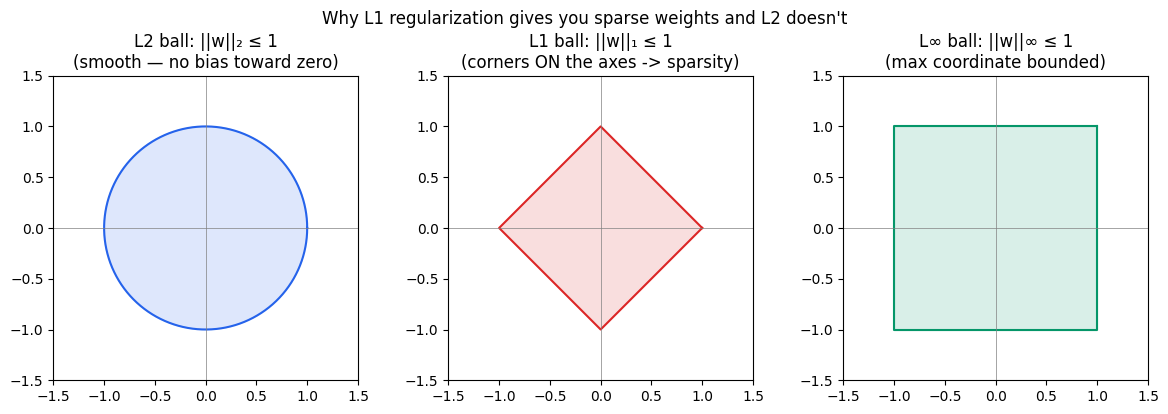

In [3]:
def visualize_norm_balls(savepath: Path = None):
    theta = np.linspace(0, 2 * np.pi, 400)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    x_l2, y_l2 = np.cos(theta), np.sin(theta)
    axes[0].plot(x_l2, y_l2, color="#2563eb")
    axes[0].fill(x_l2, y_l2, color="#2563eb", alpha=0.15)
    axes[0].set_title("L2 ball: ||w||₂ ≤ 1\n(smooth — no bias toward zero)")

    x_l1 = np.array([1, 0, -1, 0, 1]); y_l1 = np.array([0, 1, 0, -1, 0])
    axes[1].plot(x_l1, y_l1, color="#dc2626")
    axes[1].fill(x_l1, y_l1, color="#dc2626", alpha=0.15)
    axes[1].set_title("L1 ball: ||w||₁ ≤ 1\n(corners ON the axes -> sparsity)")

    x_linf = np.array([1, 1, -1, -1, 1]); y_linf = np.array([1, -1, -1, 1, 1])
    axes[2].plot(x_linf, y_linf, color="#059669")
    axes[2].fill(x_linf, y_linf, color="#059669", alpha=0.15)
    axes[2].set_title("L∞ ball: ||w||∞ ≤ 1\n(max coordinate bounded)")

    for ax in axes:
        ax.axhline(0, color="gray", linewidth=0.5)
        ax.axvline(0, color="gray", linewidth=0.5)
        ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
        ax.set_aspect("equal")

    fig.suptitle("Why L1 regularization gives you sparse weights and L2 doesn't")
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=140)
    plt.show()

visualize_norm_balls(FIG_DIR / "norm_balls.png")

Regularization adds a constraint region (the norm's "ball") that the optimal solution has to stay inside. 

The **L1 ball is a diamond with corners sitting exactly on the axes**. When the loss function's contours expand outward and touch this constraint region, they're disproportionately likely to touch at a corner - and a corner means some coordinates are *exactly* zero. 

The **L2 ball is a smooth circle with no corners**, so there's nothing pulling the solution toward exact zeros - coefficients shrink toward zero but rarely land exactly on it.

## Inner products and cosine similarity

The inner product (dot product in Euclidean space) `u · v = Σ uᵢvᵢ` measures both alignment and magnitude. Normalizing by both vectors' lengths gives you **cosine similarity**.

In [4]:
def cosine_similarity(u, v):
    return (u @ v) / (l2_norm(u) * l2_norm(v))

u = np.array([1., 0.])
v = np.array([1., 1.])
print(f"cosine_similarity({u}, {v}) = {cosine_similarity(u, v):.4f}")
print(f"cosine_similarity(v, v)     = {cosine_similarity(v, v):.4f}  (same direction -> 1)")

cosine_similarity([1. 0.], [1. 1.]) = 0.7071
cosine_similarity(v, v)     = 1.0000  (same direction -> 1)


This is the similarity metric behind nearly all embedding-based retrieval - semantic search, RAG document retrieval, recommendation systems. `cosine_similarity = 1` means same direction (maximally similar), `0` means orthogonal (unrelated), `-1` means opposite.

## Orthogonal projection - the derivation behind linear regression *and* PCA

Given a vector and a subspace, the **orthogonal projection** is the closest point in that subspace to the vector - "closest" in the sense that the leftover error (the residual) is perpendicular to the subspace.

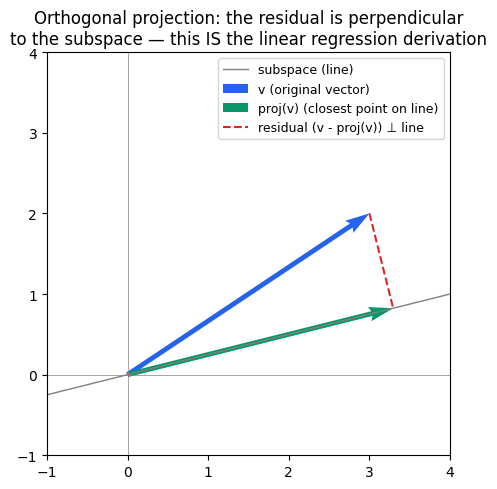

In [5]:
def project_onto_subspace(v: np.ndarray, basis: np.ndarray) -> np.ndarray:
    """Project v onto the subspace spanned by the rows of `basis`."""
    B = basis
    P = B.T @ np.linalg.inv(B @ B.T) @ B
    return P @ v

def visualize_projection_onto_line(savepath: Path = None):
    v = np.array([3.0, 2.0])
    direction = np.array([[2.0, 0.5]])
    proj = project_onto_subspace(v, direction)

    fig, ax = plt.subplots(figsize=(5, 5))
    line_t = np.linspace(-1, 2.2, 50)
    line_pts = np.outer(line_t, direction.flatten())
    ax.plot(line_pts[:, 0], line_pts[:, 1], color="gray", linewidth=1, label="subspace (line)")
    ax.quiver(0, 0, *v, angles="xy", scale_units="xy", scale=1, color="#2563eb",
              width=0.012, label="v (original vector)")
    ax.quiver(0, 0, *proj, angles="xy", scale_units="xy", scale=1, color="#059669",
              width=0.012, label="proj(v) (closest point on line)")
    ax.plot([v[0], proj[0]], [v[1], proj[1]], color="#dc2626", linestyle="--",
            label="residual (v - proj(v)) ⊥ line")

    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5)
    ax.set_xlim(-1, 4); ax.set_ylim(-1, 4)
    ax.set_aspect("equal")
    ax.legend(fontsize=9)
    ax.set_title("Orthogonal projection: the residual is perpendicular\nto the subspace — this IS the linear regression derivation")
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=140)
    plt.show()

visualize_projection_onto_line(FIG_DIR / "orthogonal_projection.png")

Notice the residual (red dashed line) meets the subspace (gray line) at a right angle. That's not a coincidence - it's the defining property: **the residual is orthogonal to the subspace precisely when you've found the closest point.**

**Why this is one of the highest-leverage ideas in the whole math track:**
- **Linear regression** - the normal equations `w = (XᵀX)⁻¹Xᵀy` are exactly this: `ŷ = Xw` is the orthogonal projection of `y` onto the column space of `X`. The residuals `y - ŷ` being orthogonal to `X`'s columns is the entire derivation.
- **PCA** - projecting data onto the top-k eigenvectors of the covariance matrix is choosing the k-dimensional subspace that minimizes total squared projection error (equivalent to maximizing retained variance).

If you can explain both of those bullets fluently, you've covered two of the most commonly-asked "derive this from scratch" ML interview questions with one geometric idea.